In [1]:
import pandas as pd
import numpy as np

In [2]:
## LOAD DATASET
df = pd.read_csv(r"C:\Users\Admin\Downloads\blogs.csv")
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [3]:
## UNDERSTAND DATA
print(df.shape)
print(df.columns)
df.info()

(2000, 2)
Index(['Data', 'Labels'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Data    2000 non-null   str  
 1   Labels  2000 non-null   str  
dtypes: str(2)
memory usage: 4.5 MB


In [4]:
## TEXT CLEANING
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

df['clean_text'] = df['Data'].apply(clean_text)

df[['Data', 'clean_text']].head()

,Data,clean_text
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupe srv cs cmu edu magnesium club ...
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,newsgroups alt atheism path cantaloupe srv cs ...
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,path cantaloupe srv cs cmu edu das news harvar...
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupe srv cs cmu edu magnesium club ...
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,xref cantaloupe srv cs cmu edu alt atheism tal...


In [5]:
## CONVERT TEXT → NUMBERS
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['Labels']

In [6]:
## TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(1600, 5000) (400, 5000)


In [7]:
## NAIVE BAYES MODEL
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [8]:
## PREDICTIONS
y_pred = model.predict(X_test)

In [9]:
## EVALUATION
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8025
                          precision    recall  f1-score   support

             alt.atheism       0.60      0.83      0.70        18
           comp.graphics       0.72      0.72      0.72        18
 comp.os.ms-windows.misc       0.81      1.00      0.90        22
comp.sys.ibm.pc.hardware       0.69      0.88      0.77        25
   comp.sys.mac.hardware       0.80      0.57      0.67        21
          comp.windows.x       0.92      0.48      0.63        25
            misc.forsale       0.78      0.78      0.78        18
               rec.autos       0.73      0.89      0.80        18
         rec.motorcycles       0.93      0.88      0.90        16
      rec.sport.baseball       0.80      0.89      0.84        18
        rec.sport.hockey       0.71      1.00      0.83        15
               sci.crypt       0.79      1.00      0.88        19
         sci.electronics       0.82      0.56      0.67        16
                 sci.med       0.88      0.88      0.88   

In [12]:
!pip install textblob

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   - ------------------------------------- 20.5/624.3 kB 330.3 kB/s eta 0:00:02
   --- ----------------------------------- 51.2/624.3 kB 525.1 kB/s eta 0:00:02
   ------------------ --------------------- 286.7/624.3 kB 2.5 MB/s eta 0:00:01
   ---------------------------------------  614.4/624.3 kB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 624.3/624.3 kB 3.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------- ----------------- 0.9/1.6 MB 26.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 19.8 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.8.1
    Uninstalling nltk-3.8.1:
      Successfully uninstalled nltk-3.8.1


In [13]:
from textblob import TextBlob

In [14]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Data'].apply(get_sentiment)

df[['Data', 'Sentiment']].head()

,Data,Sentiment
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Positive
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,Negative
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,Positive
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Positive
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,Positive


In [15]:
df['Sentiment'].value_counts()

Sentiment
Positive    1543
Negative     457
Name: count, dtype: int64

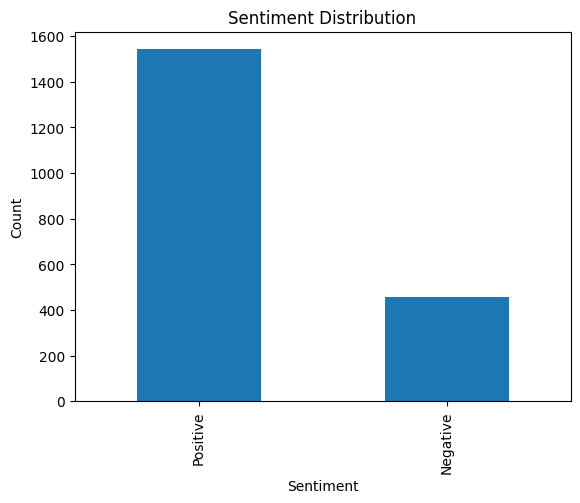

In [16]:
## ADD VISUALIZATION
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

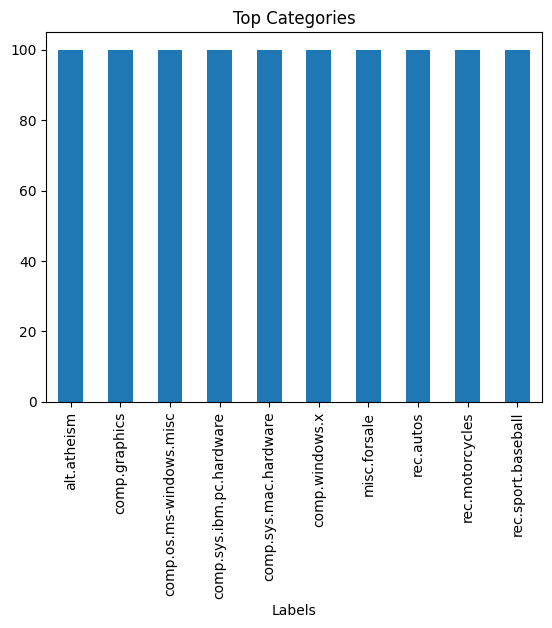

In [17]:
## CATEGORY DISTRIBUTION
df['Labels'].value_counts().head(10).plot(kind='bar')
plt.title("Top Categories")
plt.show()

## Conclusion:

The Naive Bayes model was successfully implemented for text classification.
The model achieved an accuracy of 80%, which indicates good performance.

Sentiment analysis shows that most blog posts are positive in nature,
with fewer negative posts.

TF-IDF helped convert text into numerical features effectively.
The model performs well but can be improved using advanced models like
Logistic Regression or Deep Learning.

## DISCUSSION:

- The model performs well on some categories but struggles with similar topics.
- Imbalanced sentiment distribution observed (more positive than negative).
- Text cleaning improved model performance.
- TF-IDF helped in capturing important words.

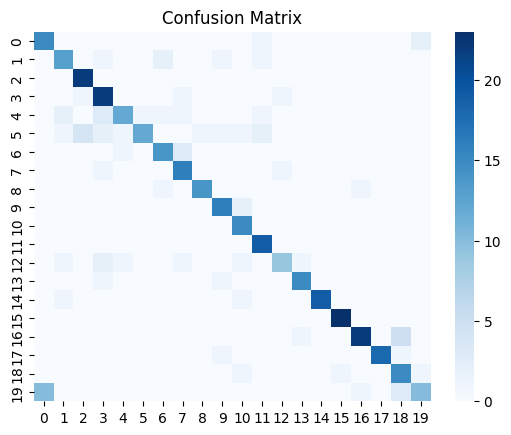

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()